# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import math
import matplotlib.pyplot as plt

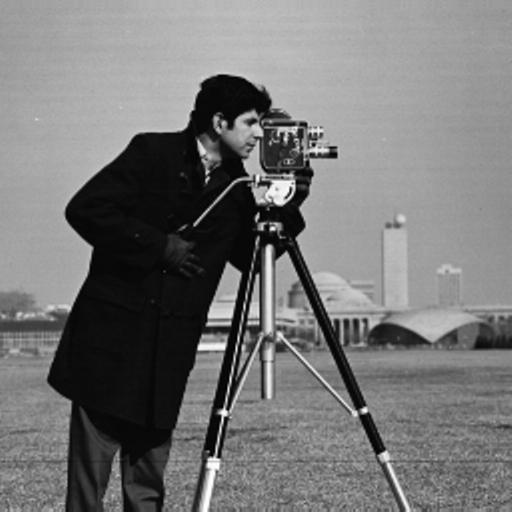

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg").convert("L")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image

# scaling factors
width, height = img.size
print("Original size:", img.size)

cx, cy = 2, 2
new_width = int(width * cx)
new_height = int(height * cy)
print("Scaled size:", (new_width, new_height))

Original size: (512, 512)
Scaled size: (1024, 1024)


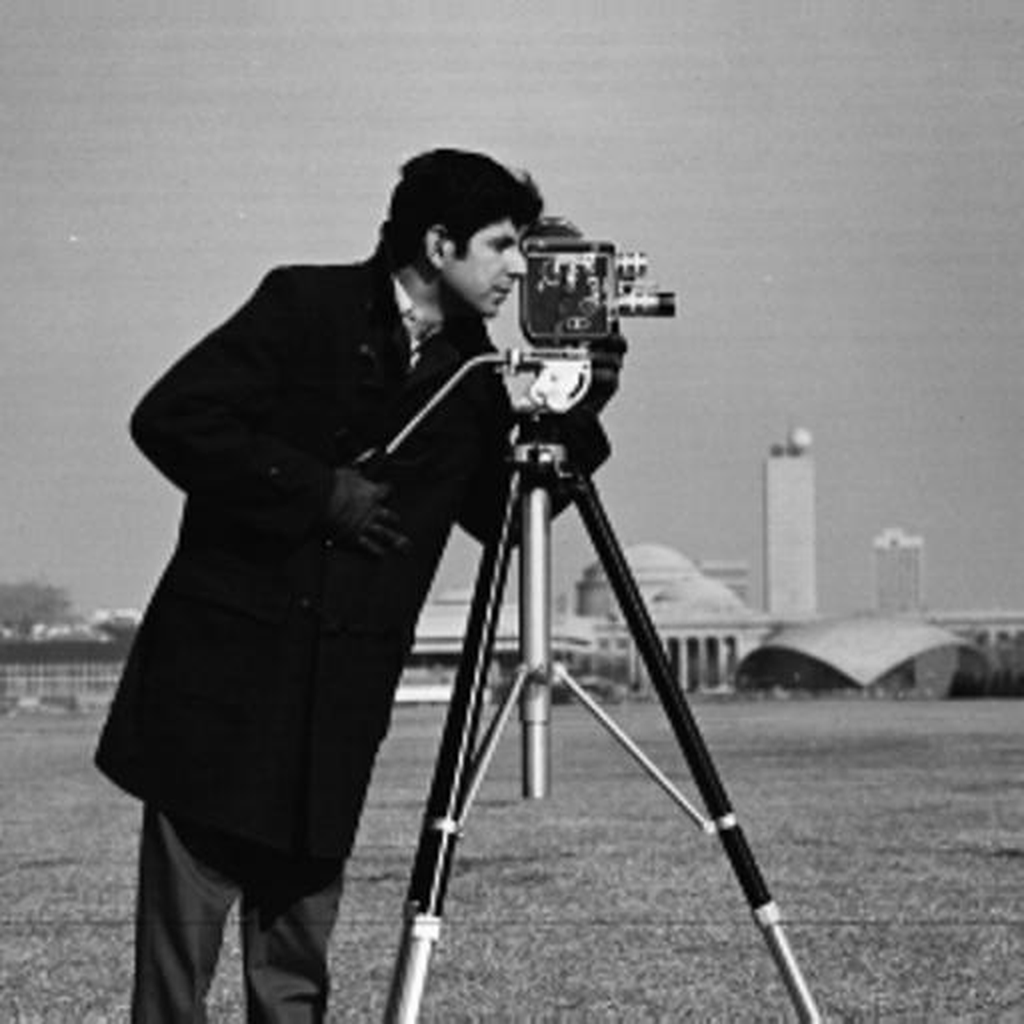

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
scaled_img

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

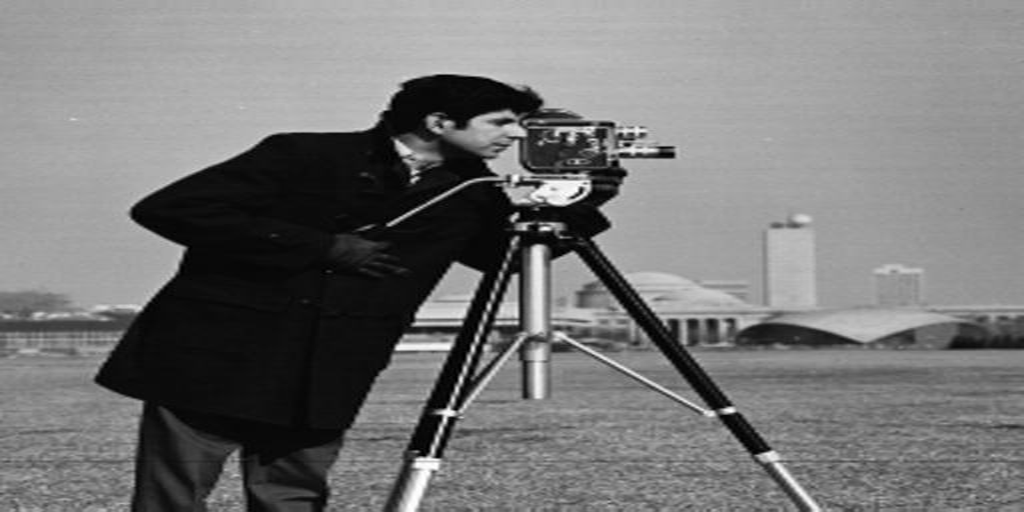

In [6]:
cx, cy = 2, 1
non_uniform_img = img.resize((int(width * cx), int(height * cy)), Image.Resampling.LANCZOS)
non_uniform_img

In [7]:
non_uniform_img.save("task1_1_nonuniform_scaled.jpg")
print("Non-uniform scaled size:", non_uniform_img.size)

Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

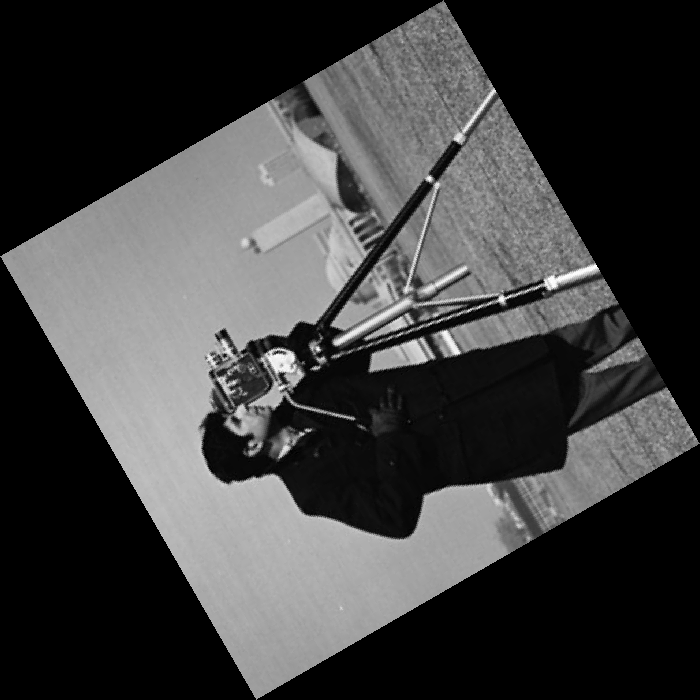

In [11]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img

In [12]:
rotated_img.save("task1_2_rotated.jpg")
print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

Original size: (512, 512)
Rotated size: (700, 700)


### 3. Shear

In [13]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [14]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

a = 1
b = shear_factor
c = 0
d = 0
e = 1
f = 0

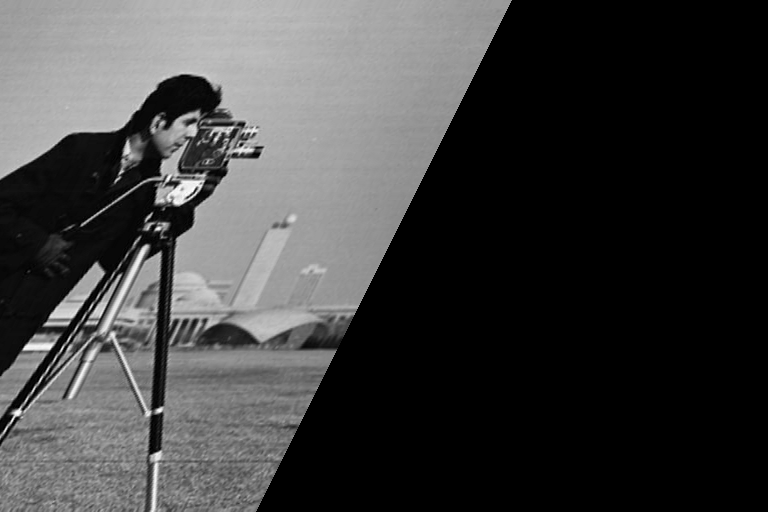

In [15]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + abs(shear_factor) * height)

sheared_img = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    (a, b, c, d, e, f),
    resample=Image.Resampling.BICUBIC
)

sheared_img

In [16]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")
print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

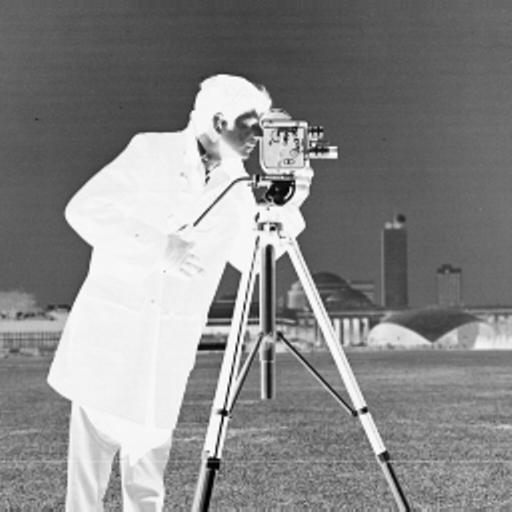

In [17]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))
negative_img



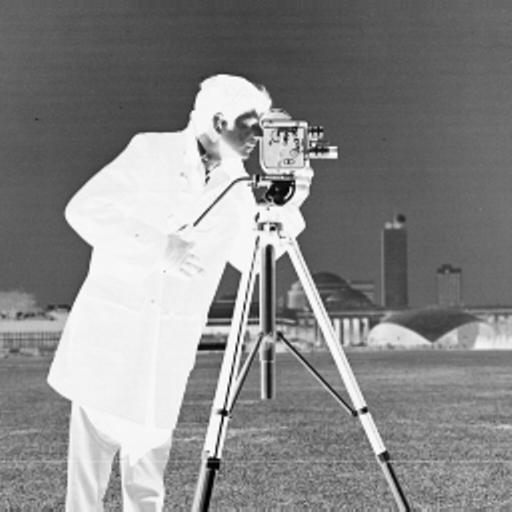

In [18]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img)
negative_img2

In [19]:
negative_img.save("task2_1_negative.jpg")
print("Negative image saved.")

Negative image saved.


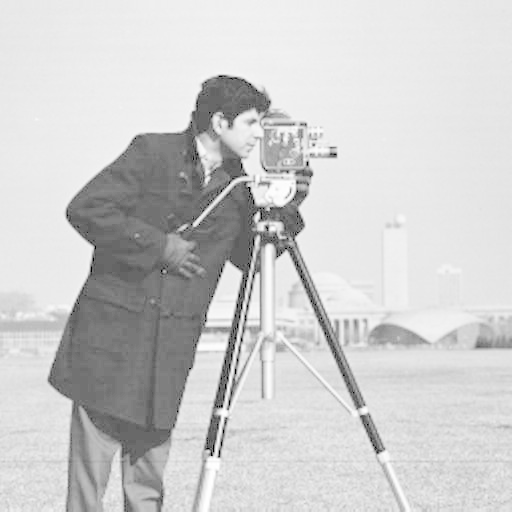

In [20]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel

arr = np.array(img, dtype=np.float32)

c = 255 / np.log(1 + 255)
log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = np.clip(log_transformed_arr, 0, 255)
log_transformed_img = Image.fromarray(log_transformed_arr.astype(np.uint8))
log_transformed_img

In [21]:
log_transformed_img.save("task2_2_log.jpg")
print("Log transformed image saved.")

Log transformed image saved.


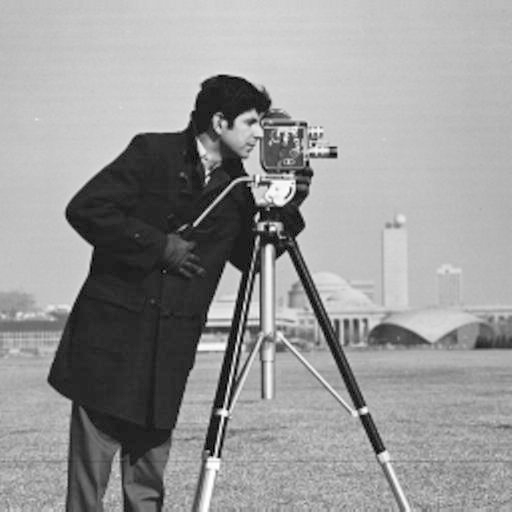

In [22]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.6

arr = np.array(img, dtype=np.float32) / 255.0
power_law_arr = 255 * (arr ** gamma)

power_law_arr = np.clip(power_law_arr, 0, 255)
power_law_img = Image.fromarray(power_law_arr.astype(np.uint8))
power_law_img

In [23]:
power_law_img.save("task2_3_gamma.jpg")
print("Gamma corrected image saved.")

Gamma corrected image saved.
